#  Customer Intelligence System
## End-to-End ML Pipeline — Classification, Ensemble & Clustering
### Dataset: Country Socio-Economic Data (Kaggle)

## IMPORTS

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

##warnings
import warnings
warnings.filterwarnings('ignore')

##preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
##dimensionality reduction 
from sklearn.decomposition import PCA

##classification models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes  import GaussianNB
from sklearn.svm  import SVC
from sklearn.neighbors  import KNeighborsClassifier
from sklearn.tree  import DecisionTreeClassifier
from sklearn.ensemble  import RandomForestClassifier
from sklearn.ensemble  import AdaBoostClassifier
from sklearn.ensemble  import GradientBoostingClassifier
from sklearn.ensemble  import StackingClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering
from sklearn_extra.cluster import KMedoids

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    silhouette_score,
    davies_bouldin_score
)

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold
)


## data loading 

In [2]:
df=pd.read_csv('Country-data.csv')

## EDA

In [3]:
print(df.shape)

(167, 10)


In [4]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [5]:
df.tail()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
162,Vanuatu,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970
163,Venezuela,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500
164,Vietnam,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310
165,Yemen,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310
166,Zambia,83.1,37.0,5.89,30.9,3280,14.00,52.0,5.40,1460


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [7]:
df.describe

<bound method NDFrame.describe of                  country  child_mort  exports  health  imports  income  \
0            Afghanistan        90.2     10.0    7.58     44.9    1610   
1                Albania        16.6     28.0    6.55     48.6    9930   
2                Algeria        27.3     38.4    4.17     31.4   12900   
3                 Angola       119.0     62.3    2.85     42.9    5900   
4    Antigua and Barbuda        10.3     45.5    6.03     58.9   19100   
..                   ...         ...      ...     ...      ...     ...   
162              Vanuatu        29.2     46.6    5.25     52.7    2950   
163            Venezuela        17.1     28.5    4.91     17.6   16500   
164              Vietnam        23.3     72.0    6.84     80.2    4490   
165                Yemen        56.3     30.0    5.18     34.4    4480   
166               Zambia        83.1     37.0    5.89     30.9    3280   

     inflation  life_expec  total_fer   gdpp  
0         9.44        56.2    

In [8]:
df.isnull().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

In [9]:
df.duplicated().sum()

0

In [10]:
df.dtypes

country        object
child_mort    float64
exports       float64
health        float64
imports       float64
income          int64
inflation     float64
life_expec    float64
total_fer     float64
gdpp            int64
dtype: object

## feature distribution 

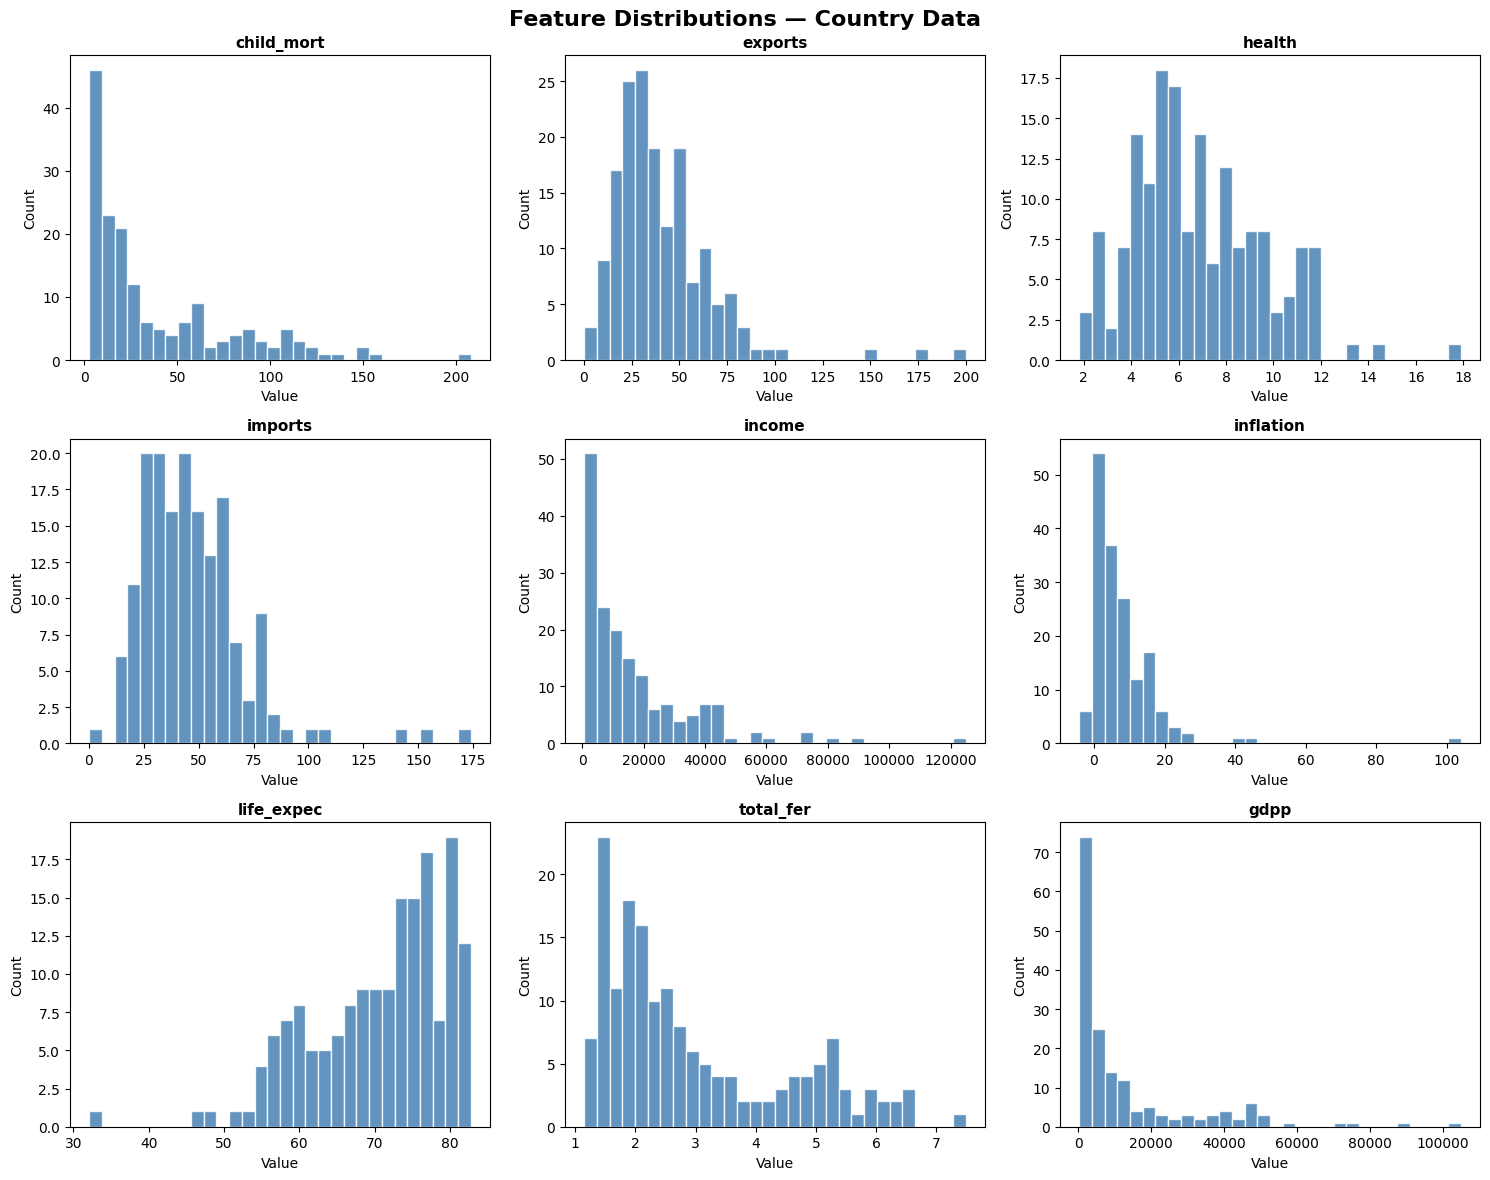

In [11]:

features = ['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']

plt.figure(figsize=(15, 12))
plt.suptitle('Feature Distributions — Country Data', fontsize=16, fontweight='bold')

for i, feat in enumerate(features):
    plt.subplot(3, 3, i + 1)
    plt.hist(df[feat], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    plt.title(feat, fontsize=11, fontweight='bold')
    plt.xlabel('Value')
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

## Correlation heatmap

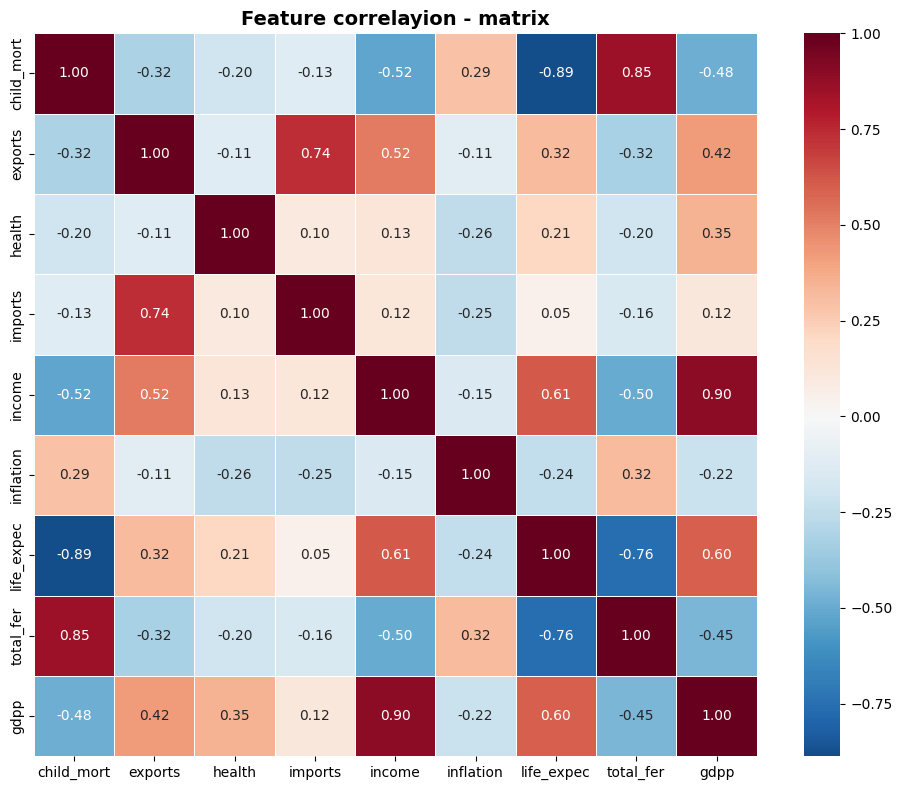

0.6

In [12]:


plt.figure(figsize=(10, 8))

corr_matrix = df[features].corr()

sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='RdBu_r', 
            center=0,
            linewidths=0.5,
            square=True)

plt.title('Feature correlayion - matrix' ,fontsize = 14, fontweight='bold')
plt.tight_layout()
plt.show()

round(corr_matrix['child_mort']['total_fer'], 3)
round(corr_matrix['child_mort']['life_expec'], 3)
round(corr_matrix['gdpp']['income'], 3)
round(corr_matrix['gdpp']['life_expec'], 3)

## boxplots 

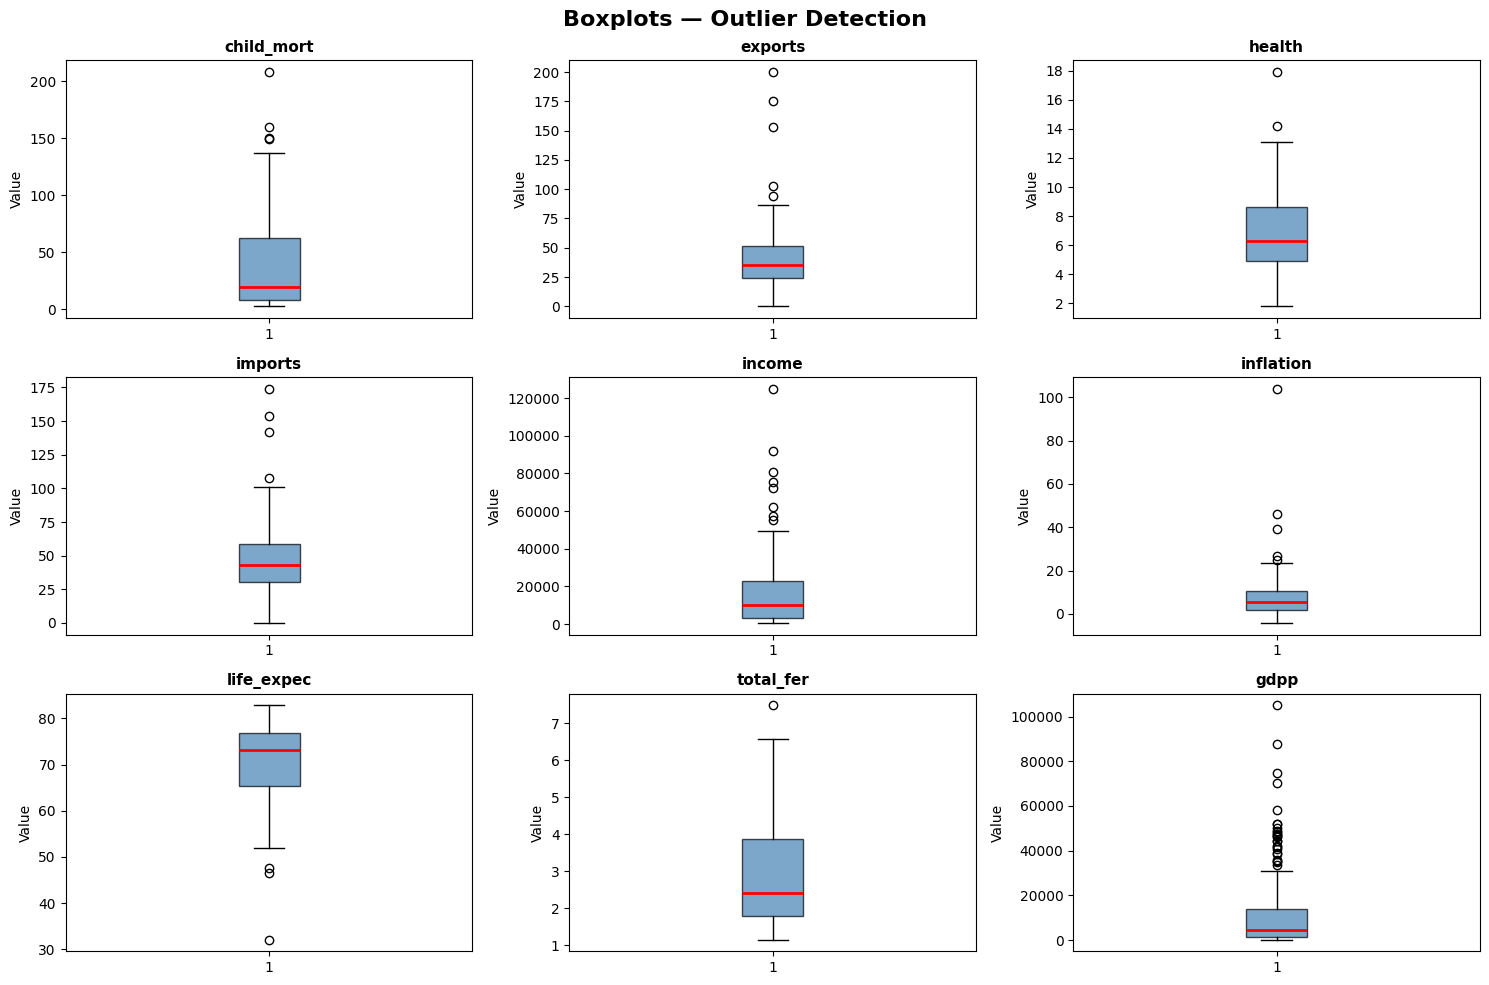

  child_mort     : 4 outliers
  exports        : 5 outliers
  health         : 2 outliers
  imports        : 4 outliers
  income         : 8 outliers
  inflation      : 5 outliers
  life_expec     : 3 outliers
  total_fer      : 1 outliers
  gdpp           : 25 outliers


In [13]:
features = ['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
fig.suptitle('Boxplots — Outlier Detection', fontsize=16, fontweight='bold')

for i, feat in enumerate(features):
    row = i // 3  
    col = i % 3    
    ax  = axes[row][col]

    ax.boxplot(df[feat],
               patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.7),
               medianprops=dict(color='red', linewidth=2))
    
    ax.set_title(feat, fontsize=11, fontweight='bold')
    ax.set_ylabel('Value')

plt.tight_layout()
plt.show()

##outliers 
for feat in features:
    Q1      = df[feat].quantile(0.25)
    Q3      = df[feat].quantile(0.75)
    IQR     = Q3 - Q1
    lower   = Q1 - 1.5 * IQR
    upper   = Q3 + 1.5 * IQR
    outliers = df[(df[feat] < lower) | (df[feat] > upper)].shape[0]
    print(f"  {feat:<15}: {outliers} outliers")

## PREPROCESSING 

In [14]:
def assign_label(row):
    score=0

    if row['gdpp'] > 20000:   score += 3   
    elif row['gdpp'] > 8000:  score += 2  
    elif row['gdpp'] > 2000:  score += 1

    if row['life_expec'] > 75:   score += 2
    elif row['life_expec'] > 65: score += 1
    
    if row['child_mort'] < 10:   score += 2
    elif row['child_mort'] < 30: score += 1
    
    if row['income'] > 20000:   score += 2
    elif row['income'] > 5000:  score += 1
    
    if score >= 7:   return 2 
    elif score >= 3: return 1   
    else:            return 0 

df['target'] = df.apply(assign_label, axis=1)

label_names = {0: 'Underdeveloped', 1: 'Developing', 2: 'Developed'}

print(df['target'].value_counts().rename(label_names))

target
Developing        62
Underdeveloped    58
Developed         47
Name: count, dtype: int64


In [15]:
## feature engineering 

df['health_per_gdpp'] = df['health'] / (df['gdpp'] + 1)

df['child_life_ratio'] = df['child_mort'] / (df['life_expec'] + 1)

df['trade_openness'] = df['exports'] + df['imports']

df['income_inflation_ratio'] = df['income'] / (df['inflation'] + 1)

df['gdpp_per_fertility'] = df['gdpp'] / (df['total_fer'] + 1)

new_features = ['health_per_gdpp', 'child_life_ratio', 
                'trade_openness', 'income_inflation_ratio',
                'gdpp_per_fertility']

print(df[new_features].head())
print(f"\nTotal features ab: {len(df.columns)} columns")

features = ['child_mort', 'exports', 'health', 'imports',
            'income', 'inflation', 'life_expec', 'total_fer', 'gdpp',
            'health_per_gdpp', 'child_life_ratio', 'trade_openness',
            'income_inflation_ratio', 'gdpp_per_fertility']

print({len(features)})


   health_per_gdpp  child_life_ratio  trade_openness  income_inflation_ratio  \
0         0.013682          1.576923            54.9              154.214559   
1         0.001601          0.214748            76.6             1808.743169   
2         0.000935          0.352258            69.8              754.385965   
3         0.000807          1.947627           105.2              252.136752   
4         0.000494          0.132391           104.4             7827.868852   

   gdpp_per_fertility  
0           81.085044  
1         1543.396226  
2         1146.529563  
3          493.016760  
4         3897.763578  

Total features ab: 16 columns
{14}


In [16]:
## feature encoding 
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['country_encoded'] = le.fit_transform(df['country'])

print(df[['country', 'country_encoded']].head(10))

               country  country_encoded
0          Afghanistan                0
1              Albania                1
2              Algeria                2
3               Angola                3
4  Antigua and Barbuda                4
5            Argentina                5
6              Armenia                6
7            Australia                7
8              Austria                8
9           Azerbaijan                9


In [17]:
## train_test_split

X=df[features]
y=df['target']

print(X.shape , y.shape)

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

print(X_train.shape[0])
print(X_test.shape[0])
## feature scaling
scaler=StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(round(X_train_scaled.mean(),4))
print(round(X_test_scaled.mean(),4))

(167, 14) (167,)
133
34
-0.0
-0.0365


In [18]:
## PCA

pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(X_train.shape)
print(X_train_pca.shape)

print(pca.explained_variance_ratio_.sum())

(133, 14)
(133, 7)
0.95668291341864


## Classification

In [27]:
def evaluate_model(model_name, y_test, y_pred):
    print(model_name)

    acc  = accuracy_score(y_test, y_pred)
    print(acc *  100 , 2)

    prec = precision_score(y_test, y_pred, average='weighted')
    print(prec *  100 , 2)

    rec = recall_score(y_test, y_pred, average='weighted')
    print(rec *  100 , 2)

    f1 = f1_score(y_test, y_pred, average='weighted')
    print(f1 *  100 , 2)

    cm = confusion_matrix(y_test, y_pred, average='weighted')
    print(cm *  100 , 2)

    print('classification_report')
    print(classification_report(y_test, y_pred,target_names=['Underdeveloped', 'Developing', 'Developed']))

    results[model_name] = {
        'Accuracy' : round(acc,  4),
        'Precision': round(prec, 4),
        'Recall'   : round(rec,  4),
        'F1 Score' : round(f1,   4)
    }
results = {}



[[12  0  0]
 [ 0 13  0]
 [ 0  4  5]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.76      1.00      0.87        13
           2       1.00      0.56      0.71         9

    accuracy                           0.88        34
   macro avg       0.92      0.85      0.86        34
weighted avg       0.91      0.88      0.87        34

Logistic Accuracy: 0.8823529411764706


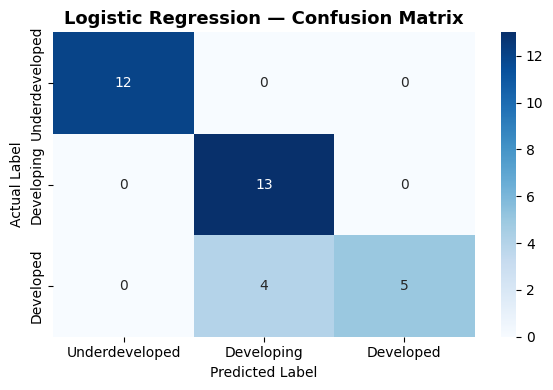

In [78]:
## logistic regression 

lr_model=LogisticRegression(max_iter=1000,random_state=42)

lr_model.fit(X_train_scaled,y_train)

lr_pred=lr_model.predict(X_test_scaled)

cm = confusion_matrix(y_test,lr_pred)

print(cm)

print(classification_report(y_test, lr_pred))

print("Logistic Accuracy:",accuracy_score(y_test, lr_pred))

plt.figure(figsize=(6, 4))

sns.heatmap(cm,annot=True, fmt='d', cmap='Blues',
            xticklabels=['Underdeveloped', 'Developing', 'Developed'],
            yticklabels=['Underdeveloped', 'Developing', 'Developed'])

plt.title('Logistic Regression — Confusion Matrix',fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label')   
plt.ylabel('Actual Label')    
plt.tight_layout()
plt.show()

[[12  0  0]
 [ 1 10  2]
 [ 0  2  7]]
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        12
           1       0.83      0.77      0.80        13
           2       0.78      0.78      0.78         9

    accuracy                           0.85        34
   macro avg       0.84      0.85      0.85        34
weighted avg       0.85      0.85      0.85        34

Naive Bayes Accuracy: 0.8529411764705882


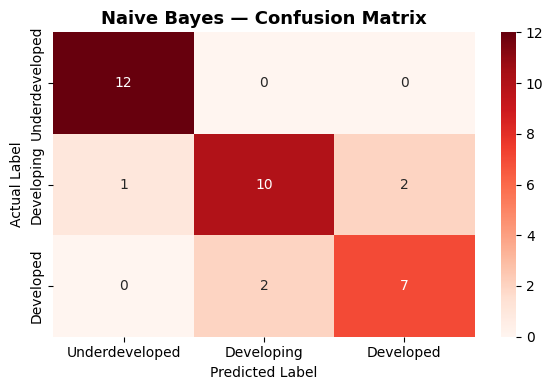

In [79]:
## naive bayes

nb_model = GaussianNB()

nb_model.fit(X_train_scaled,y_train)

nb_pred=nb_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, nb_pred)

print(cm)

print(classification_report(y_test, nb_pred))

print("Naive Bayes Accuracy:",
      accuracy_score(y_test, nb_pred))

plt.figure(figsize=(6, 4))
sns.heatmap(cm,annot=True, fmt='d', cmap='Reds',
            xticklabels=['Underdeveloped', 'Developing', 'Developed'],
            yticklabels=['Underdeveloped', 'Developing', 'Developed'])

plt.title('Naive Bayes — Confusion Matrix',fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()

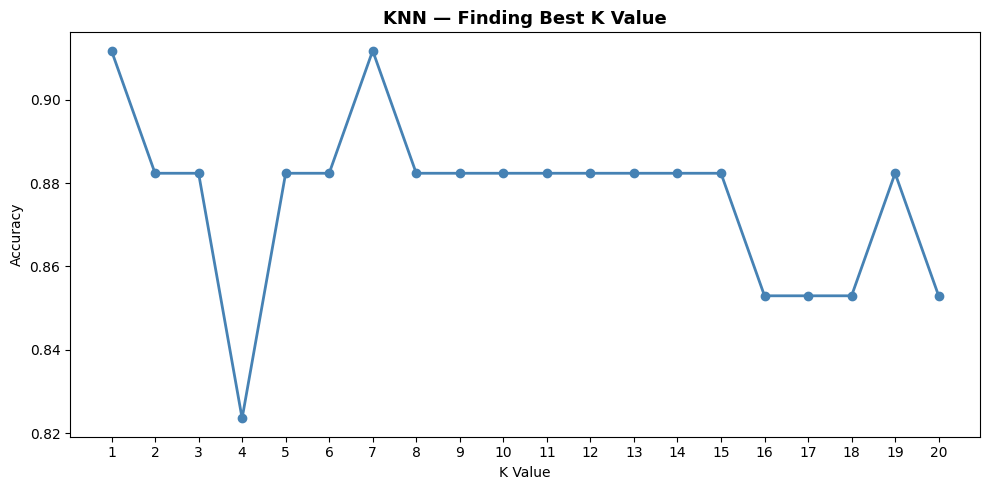

In [21]:
## knn (k-nearest-neighbor)

k_scores = []

for k in range(1, 21): 
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    score = knn.score(X_test_scaled, y_test) 
    k_scores.append(score)

plt.figure(figsize=(10, 5))

plt.plot(range(1, 21), k_scores,  marker='o', color='steelblue', linewidth=2)

plt.title('KNN — Finding Best K Value', fontsize=13, fontweight='bold')

plt.xlabel('K Value')        
plt.ylabel('Accuracy')       
plt.xticks(range(1, 21))     
plt.tight_layout()
plt.show()


[[12  0  0]
 [ 0 13  0]
 [ 0  4  5]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.76      1.00      0.87        13
           2       1.00      0.56      0.71         9

    accuracy                           0.88        34
   macro avg       0.92      0.85      0.86        34
weighted avg       0.91      0.88      0.87        34

Support vector machine: 0.8529411764705882


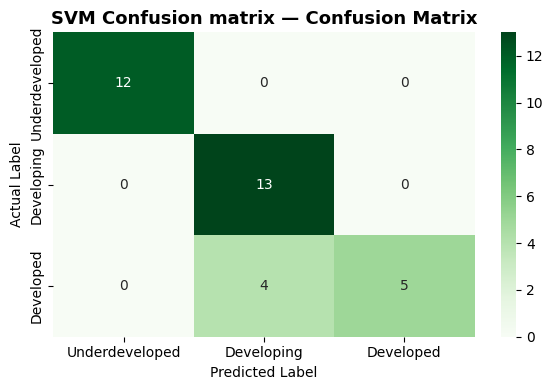

In [ ]:
## svm (Support vector machine)

svm_model = SVC(kernel='rbf',C=1.0,random_state=42)

svm_model.fit(X_train_scaled,y_train)
svm_pred=svm_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, svm_pred)

print(cm)

print(classification_report(y_test, svm_pred))

print("Support vector machine:",accuracy_score(y_test, nb_pred))

plt.figure(figsize=(6, 4))
sns.heatmap(cm,annot=True, fmt='d', cmap='Greens',
            xticklabels=['Underdeveloped', 'Developing', 'Developed'],
            yticklabels=['Underdeveloped', 'Developing', 'Developed'])

plt.title('SVM Confusion matrix — Confusion Matrix',
          fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()

[[12  0  0]
 [ 0 11  2]
 [ 0  2  7]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.85      0.85      0.85        13
           2       0.78      0.78      0.78         9

    accuracy                           0.88        34
   macro avg       0.87      0.87      0.87        34
weighted avg       0.88      0.88      0.88        34

DECISION TREE : 0.8529411764705882


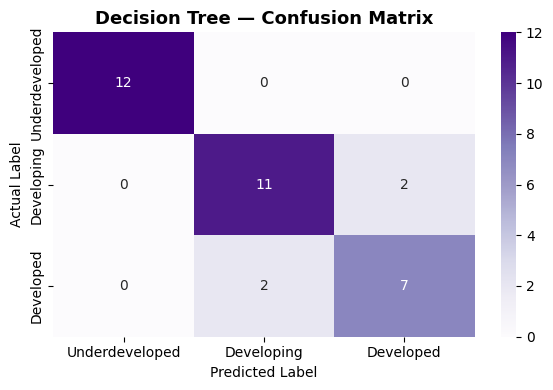

In [81]:
## DECISION TREE 

dt_model = DecisionTreeClassifier(max_depth=5,random_state=42)

dt_model.fit(X_train_scaled,y_train)
dt_pred=dt_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, dt_pred)

print(cm)

print(classification_report(y_test, dt_pred))

print("DECISION TREE :",accuracy_score(y_test, nb_pred))

plt.figure(figsize=(6, 4))
sns.heatmap(cm,annot=True, fmt='d', cmap='Purples',
            xticklabels=['Underdeveloped', 'Developing', 'Developed'],
            yticklabels=['Underdeveloped', 'Developing', 'Developed'])

plt.title('Decision Tree — Confusion Matrix',
          fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()


## ENSEMBLE LEARNING 

[[12  0  0]
 [ 0 11  2]
 [ 0  2  7]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.85      0.85      0.85        13
           2       0.78      0.78      0.78         9

    accuracy                           0.88        34
   macro avg       0.87      0.87      0.87        34
weighted avg       0.88      0.88      0.88        34



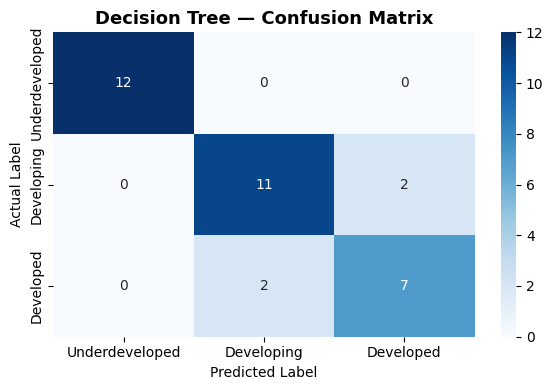

In [75]:
##RANDOM FOREST  

rf_model = RandomForestClassifier(n_estimators=100,max_depth=5,random_state=42)

rf_model.fit(X_train_scaled,y_train)
rf_pred=rf_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, dt_pred)

print(cm)

print(classification_report(y_test, rf_pred))

plt.figure(figsize=(6, 4))
sns.heatmap(cm,annot=True, fmt='d', cmap='Blues',
            xticklabels=['Underdeveloped', 'Developing', 'Developed'],
            yticklabels=['Underdeveloped', 'Developing', 'Developed'])

plt.title('Decision Tree — Confusion Matrix',
          fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()


[[12  0  0]
 [ 0 12  1]
 [ 0  2  7]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.86      0.92      0.89        13
           2       0.88      0.78      0.82         9

    accuracy                           0.91        34
   macro avg       0.91      0.90      0.90        34
weighted avg       0.91      0.91      0.91        34



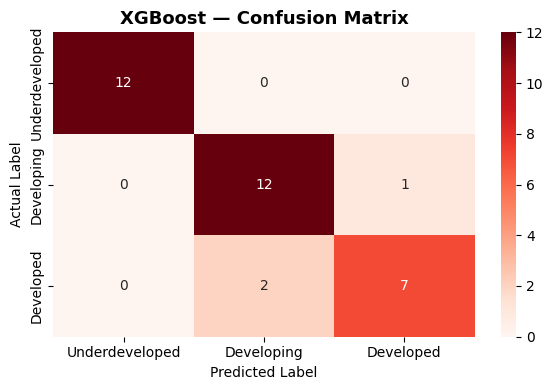

In [76]:
## XGBoost 

xgb_model = XGBClassifier(n_estimators=100,learning_rate=0.1,max_depth=5,random_state=42,use_label_encoder=False,eval_metric='mlogloss')

xgb_model.fit(X_train_scaled,y_train)
xgb_pred=xgb_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, xgb_pred)

print(cm)

print(classification_report(y_test, xgb_pred))

plt.figure(figsize=(6, 4))
sns.heatmap(cm,annot=True, fmt='d', cmap='Reds',
            xticklabels=['Underdeveloped', 'Developing', 'Developed'],
            yticklabels=['Underdeveloped', 'Developing', 'Developed'])

plt.title('XGBoost — Confusion Matrix',
          fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()


## clustering 

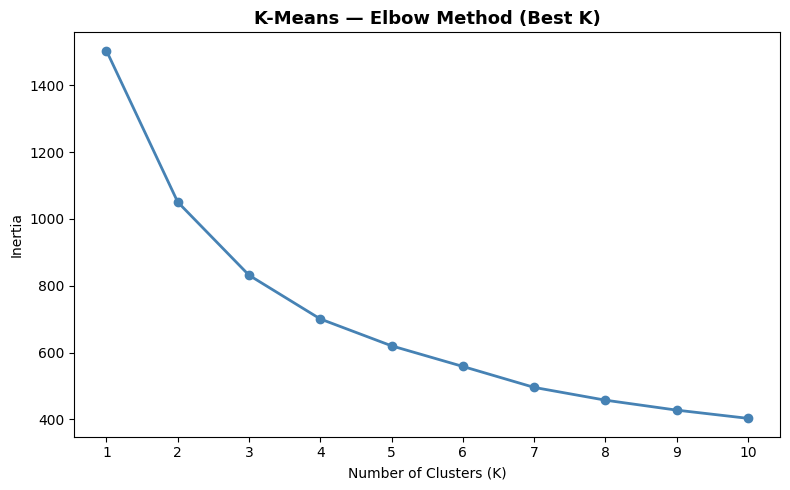

  K=2 → Silhouette Score: 0.2874
  K=3 → Silhouette Score: 0.2833
  K=4 → Silhouette Score: 0.2960
  K=5 → Silhouette Score: 0.2993
  K=6 → Silhouette Score: 0.2287
  K=7 → Silhouette Score: 0.2477
  K=8 → Silhouette Score: 0.2388
  K=9 → Silhouette Score: 0.2073
  K=10 → Silhouette Score: 0.2022

 Best K = 5
kmeans_cluster
0    84
1    47
3    32
2     3
4     1
Name: count, dtype: int64


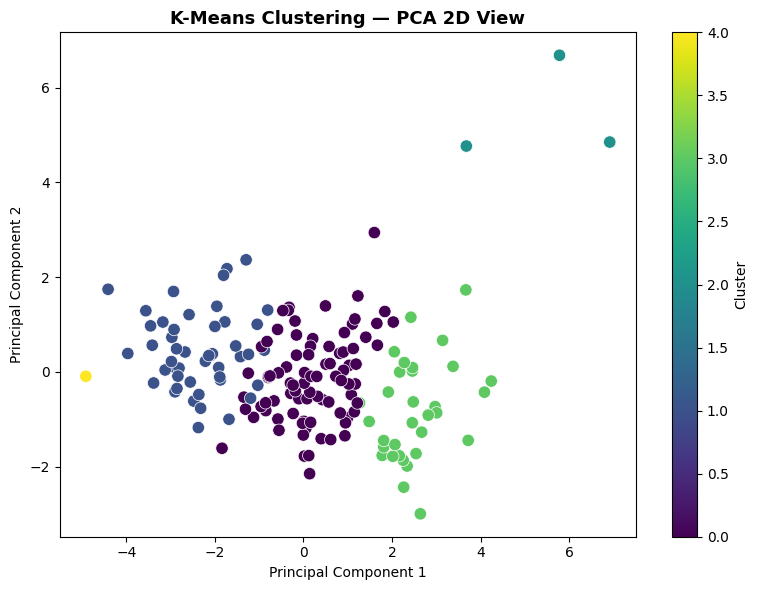


 Cluster Profiles (Mean Values):
                child_mort  life_expec      gdpp    income
kmeans_cluster                                            
0                    21.61       73.00   6581.81  12801.07
1                    90.79       59.21   1900.26   3870.70
2                     4.13       81.43  57566.67  64033.33
3                     5.18       80.08  42118.75  44021.88
4                   130.00       60.50   2330.00   5150.00


In [59]:
## k means clustering 

X_cluster = df[['child_mort', 'exports', 'health', 'imports','income', 'inflation', 'life_expec','total_fer', 'gdpp']]

scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

inertias = [] 

for k in range(1, 11): 
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertias, marker='o', color='steelblue', linewidth=2)
plt.title('K-Means — Elbow Method (Best K)',fontsize=13, fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(range(1, 11))
plt.tight_layout()
plt.show()


## silhoutte_score 

sil_scores = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster_scaled)
    score = silhouette_score(X_cluster_scaled, labels)
    sil_scores.append(score)
    print(f"  K={k} → Silhouette Score: {score:.4f}")

best_k = sil_scores.index(max(sil_scores)) + 2
print(f"\n Best K = {best_k}")

kmeans_model = KMeans(
    n_clusters=best_k,  
    random_state=42,
    n_init=10       
)

df['kmeans_cluster'] = kmeans_model.fit_predict(X_cluster_scaled)

print(df['kmeans_cluster'].value_counts())

## using PCA for 2 d vsiualization 
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=df['kmeans_cluster'],
                      cmap='viridis', s=80,
                      edgecolors='white', linewidths=0.5)

plt.colorbar(scatter, label='Cluster')

plt.title('K-Means Clustering — PCA 2D View',fontsize=13, fontweight='bold')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.tight_layout()
plt.show()

print("\n Cluster Profiles (Mean Values):")
print(df.groupby('kmeans_cluster')[['child_mort', 'life_expec', 'gdpp', 'income']].mean().round(2))


DBSCAN — Different eps Values:
  eps=0.3 → Clusters=0, Noise=167
  eps=0.5 → Clusters=0, Noise=167
  eps=0.7 → Clusters=1, Noise=162
  eps=1.0 → Clusters=3, Noise=94
  eps=1.2 → Clusters=3, Noise=53
  eps=1.5 → Clusters=1, Noise=30

 DBSCAN Results:
  Clusters Found : 3
  Noise Points   : 94

  Cluster Distribution:
dbscan_cluster
-1    94
 0    52
 1    16
 2     5
Name: count, dtype: int64


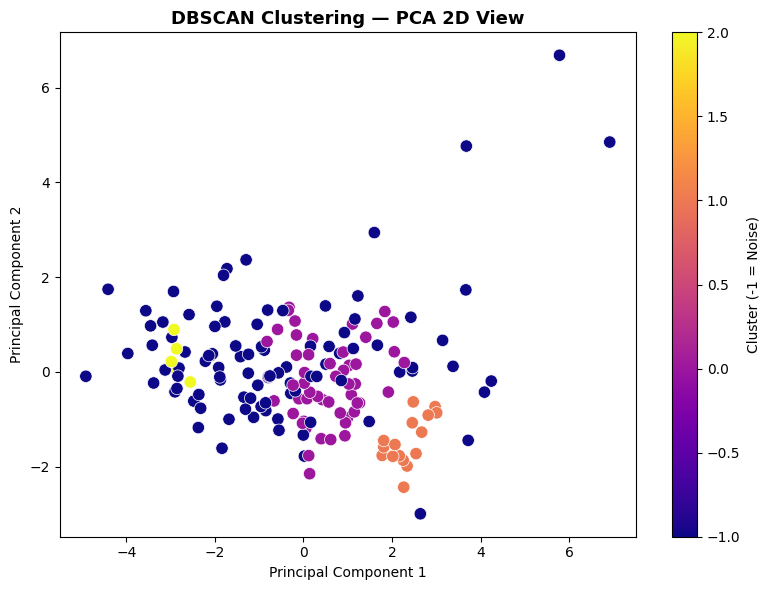

In [61]:
##dbscan cLUSTERING 

print("DBSCAN — Different eps Values:")
for eps in [0.3, 0.5, 0.7, 1.0, 1.2, 1.5]:
    db = DBSCAN(eps=eps, min_samples=5)
    labels = db.fit_predict(X_cluster_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise    = (labels == -1).sum()
    print(f"  eps={eps} → Clusters={n_clusters}, Noise={n_noise}")

    dbscan_model = DBSCAN(eps=1.0,min_samples=5 )

    df['dbscan_cluster'] = dbscan_model.fit_predict(X_cluster_scaled)

n_clusters = len(set(df['dbscan_cluster'])) - \
             (1 if -1 in df['dbscan_cluster'].values else 0)
n_noise    = (df['dbscan_cluster'] == -1).sum()

print(f"\n DBSCAN Results:")
print(f"  Clusters Found : {n_clusters}")
print(f"  Noise Points   : {n_noise}")
print(f"\n  Cluster Distribution:")
print(df['dbscan_cluster'].value_counts()) 

## using PCA for 2d visualization

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=df['dbscan_cluster'],
                      cmap='plasma', s=80,
                      edgecolors='white', linewidths=0.5)
plt.colorbar(scatter, label='Cluster (-1 = Noise)')
plt.title('DBSCAN Clustering — PCA 2D View',
          fontsize=13, fontweight='bold')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.tight_layout()
plt.show()

# Final Summary

| Step | What we did |
|---|---|
| **Data Loading** | Loaded country-level socio-economic dataset and explored structure, datatypes, duplicates, and missing values |
| **EDA** | Performed feature distributions, boxplots, correlation heatmap, and country development trend analysis |
| **Data Cleaning** | Checked duplicates, missing values, datatype consistency, and dataset quality |
| **Feature Engineering** | Created meaningful features such as **health_per_gdpp**, **child_life_ratio**, and **trade_openness** |
| **Target Creation** | Built a custom **country development classification target** using GDP, life expectancy, child mortality, and income-based scoring |
| **Encoding** | Applied **Label Encoding** on country names for numerical representation |
| **Feature Scaling** | Used **StandardScaler** to normalize features and improve model performance |
| **Train-Test Split** | Split dataset into training and testing sets using **stratified sampling** to maintain class balance |
| **Dimensionality Reduction** | Applied **PCA (95% variance retained)** to reduce dimensions while preserving important information |
| **Classification Models** | Trained and compared **Logistic Regression, Naive Bayes, KNN, SVM, and Decision Tree** classifiers |
| **Ensemble Learning** | Implemented **Random Forest** and **XGBoost** for stronger predictive performance |
| **Evaluation** | Used **Accuracy, Precision, Recall, F1-score, Confusion Matrix, and Classification Report** for model comparison |
| **Hyperparameter Tuning** | Experimented with model parameters such as **K values** and estimator settings |
| **Clustering** | Applied **K-Means** and **DBSCAN** clustering to group countries using socio-economic indicators |
| **Learning** | GDP, life expectancy, child mortality, and income strongly influence country development. Feature engineering + ensemble models improved classification performance, while clustering revealed natural country groupings. |